In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from tqdm import tqdm

In [ ]:
TRAIN_IMAGE_DIR = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/train'
CSV_PATH = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/train.csv'
TEST_IMAGE_DIR = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/test'

BATCH_SIZE = 8
EPOCHS = 20
LEARNING_RATE = 0.0001
NUM_CLASSES = 13

In [ ]:
# Load and prepare the dataset
df = pd.read_csv(CSV_PATH)
label_columns = df.columns[1:]  # Skip 'id'
df['filename'] = 'L' + df['id'].astype(str).str.strip() + '.JPG'

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

class ChocolateDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        filename = row['filename'].strip().lower()
        img_path = os.path.normpath(os.path.join(TRAIN_IMAGE_DIR, filename))
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = row[label_columns].values.astype(np.float32)
        return image, torch.tensor(labels, dtype=torch.float32)

train_ds = ChocolateDataset(train_df, transform=transform)
val_ds = ChocolateDataset(val_df, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

### First model without annotated data

In [ ]:
# Define the model
class ChocolateCNN(nn.Module):
    def __init__(self, num_outputs):
        super(ChocolateCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.attention_conv = nn.Conv2d(128, 1, kernel_size=1)
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, num_outputs)
        )

    # def forward(self, x):
    #     x = self.features(x)
    #     x = x.view(x.size(0), -1)
    #     return self.classifier(x)
    
    # def forward(self, x):
    #     features = self.features(x)
    #     attn_map = self.attention_conv(features)
    #     attn_map = attn_map.view(features.size(0), -1)
    #     attn_map = torch.softmax(attn_map, dim=-1)
    #     features_flat = features.view(features.size(0), features.size(1), -1)
    #     attn_pooled = torch.bmm(features_flat, attn_map.unsqueeze(2)).squeeze(2)
    #     output = self.classifier(attn_pooled)
    #     return output
    
    def forward(self, x):
        features = self.features(x)  # (B, 128, H, W)
        B, C, H, W = features.shape

        # Attention map
        attn_map = self.attention_conv(features)  # (B, 1, H, W)
        attn_map = attn_map.flatten(start_dim=2)   # (B, 1, H*W)
        attn_map = torch.softmax(attn_map, dim=-1) # softmax over spatial

        features_flat = features.flatten(start_dim=2)  # (B, 128, H*W)

        attn_pooled = torch.bmm(features_flat, attn_map.transpose(1, 2)).squeeze(2)

        output = self.classifier(attn_pooled)
        return output

model = ChocolateCNN(num_outputs=NUM_CLASSES)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

ChocolateCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (attention_conv): Conv2d(128, 1, kernel_size=(1, 1), stride=(1, 1))
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=13, bias=True)
  )
)

In [37]:
# Training
# criterion = nn.MSELoss()
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
    scheduler.step()
    
    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_val_loss = val_loss / len(val_loader.dataset)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss/len(train_loader.dataset):.4f}, Val Loss: {val_loss/len(val_loader.dataset):.4f}")

# Save the model
torch.save(model.state_dict(), 'chocolate_count_model.pth')

100%|██████████| 3/3 [00:20<00:00,  6.69s/it]


Epoch 1/20, Train Loss: 0.3444, Val Loss: 0.3107


100%|██████████| 3/3 [00:20<00:00,  6.85s/it]


Epoch 2/20, Train Loss: 0.3122, Val Loss: 0.3015


100%|██████████| 3/3 [00:19<00:00,  6.34s/it]


...

Epoch 18/20, Train Loss: 0.2881, Val Loss: 0.2903


100%|██████████| 3/3 [00:20<00:00,  6.82s/it]


Epoch 19/20, Train Loss: 0.2881, Val Loss: 0.2905


100%|██████████| 3/3 [00:20<00:00,  6.89s/it]


Epoch 20/20, Train Loss: 0.2881, Val Loss: 0.2903


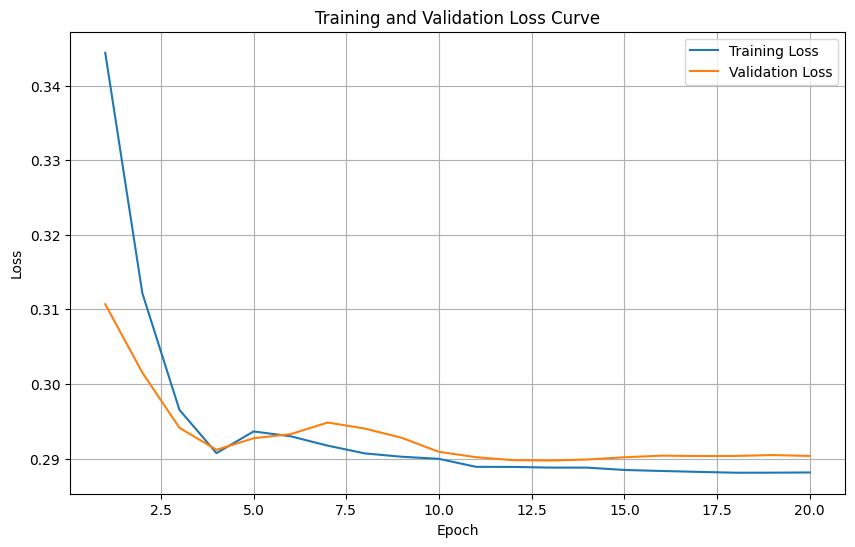

In [38]:

plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
# Prediction and submission file creation
def predict_and_create_submission(model, submission_template_path, output_csv_path):
    submission_df = pd.read_csv(submission_template_path)
    image_ids = submission_df['id'].tolist()
    filenames = ['L' + str(i) + '.JPG' for i in image_ids]

    results = []
    for img_id, fname in zip(image_ids, filenames):
        img_path = os.path.normpath(os.path.join(TEST_IMAGE_DIR, fname))
        if not os.path.exists(img_path):
            print(f"Skipping missing image: {img_path}")
            results.append([img_id] + [0]*NUM_CLASSES)
            continue
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(img_tensor).cpu().numpy().flatten()
        predicted_counts = np.clip(np.round(output), 0, None).astype(int)
        results.append([img_id] + predicted_counts.tolist())

    result_df = pd.DataFrame(results, columns=['id'] + label_columns.tolist())
    result_df.to_csv(output_csv_path, index=False)
    print(f"Submission saved to {output_csv_path}")

In [40]:
sample_submission_path = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/sample_submission.csv'
test_submission_path = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/predictions/attn_CNN_submission.csv'
predict_and_create_submission(model, sample_submission_path, test_submission_path)

Submission saved to C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/predictions/attn_CNN_submission.csv
